In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/ahmendabad_house_price.csv')

## 1.Data Understanding

In [4]:
df.head()

,name,location,description,rate_per_sqft,area_in_sqft,area_type,property_title,property_type,bhk_type,price_in_cr
0,swarnim sentossa,swarnim sentossa,let your dream of owning a flat come true with...,5009.0,2250.0,super,swarnim sentossa,flat,3,NaN
1,scarlet springs,scarlet springs,"scarlet springs is a residential project, offe...",4377.0,1674.0,super,scarlet springs,flat,3,0.7328
2,suryansh sanidhya shivalaya,"sarkhej, sarkhej okaf, ahmedabad",suryansh sanidhya shivalaya society now offers...,3931.0,1080.0,super,suryansh sanidhya shivalaya,flat,2,0.4245
3,siddhi terrace skyline,memnagar,"siddhi terrace skyline, one of the known housi...",7198.0,2320.0,super,siddhi terrace skyline,flat,3,1.6700
4,aadhya arambh,"ghatlodia, ahmedabad","beautiful 3,4 bhk apartments in ghatlodia, are...",NaN,1604.0,carpet,aadhya arambh,flat,4,NaN


In [5]:
df.shape

(20060, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20060 entries, 0 to 20059
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            19950 non-null  object 
 1   location        19765 non-null  object 
 2   description     20045 non-null  object 
 3   rate_per_sqft   19701 non-null  float64
 4   area_in_sqft    20036 non-null  float64
 5   area_type       20060 non-null  object 
 6   property_title  19949 non-null  object 
 7   property_type   20060 non-null  object 
 8   bhk_type        20060 non-null  int64  
 9   price_in_cr     19332 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 1.5+ MB


In [7]:
df.describe()

,rate_per_sqft,area_in_sqft,bhk_type,price_in_cr
count,1.970100e+04,2.003600e+04,20060.000000,19332.000000
mean,1.375771e+04,3.123944e+03,2.903988,1.462586
std,2.134984e+05,7.027497e+04,1.207127,2.101026
min,0.000000e+00,1.000000e+00,1.000000,0.010000
25%,4.620000e+03,1.000000e+03,2.000000,0.550000
50%,6.153000e+03,1.500000e+03,3.000000,0.850000
75%,8.860000e+03,2.169000e+03,3.000000,1.550000
max,1.500000e+07,6.534000e+06,45.000000,120.000000


In [8]:
for i in df.columns:
  print(df[i].value_counts())
  print('='* 30)

name
godrej garden city             74
safal riviera aspire           71
savvy swaraaj sports living    58
godrej green glades            49
archway by adani realty        46
                               ..
hrishiraj h4                    1
sonnet opus                     1
antriksh complex                1
aaradhya apartment              1
adoor arise                     1
Name: count, Length: 7291, dtype: int64
location
science city, ahmedabad        88
godrej garden city             74
sola, ahmedabad                72
safal riviera aspire           59
savvy swaraaj sports living    55
                               ..
sentosa greenland               1
shreekar celestial living       1
shree ram residency             1
roseville                       1
on reqeust                      1
Name: count, Length: 7282, dtype: int64
description
a quiet and beautiful apartment located in heart of the city is available on sale in ahmedabad. property is nicely located with all facilities nea

## 2.Missing Value Handling

In [9]:
df.isnull().sum()

,0
name,110
location,295
description,15
rate_per_sqft,359
area_in_sqft,24
area_type,0
property_title,111
property_type,0
bhk_type,0
price_in_cr,728


In [10]:
df = df.drop(['description','name','property_title'],axis=1)

In [11]:
df.head()

,location,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
0,swarnim sentossa,5009.0,2250.0,super,flat,3,NaN
1,scarlet springs,4377.0,1674.0,super,flat,3,0.7328
2,"sarkhej, sarkhej okaf, ahmedabad",3931.0,1080.0,super,flat,2,0.4245
3,memnagar,7198.0,2320.0,super,flat,3,1.6700
4,"ghatlodia, ahmedabad",NaN,1604.0,carpet,flat,4,NaN


In [12]:
df.head()

,location,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
0,swarnim sentossa,5009.0,2250.0,super,flat,3,NaN
1,scarlet springs,4377.0,1674.0,super,flat,3,0.7328
2,"sarkhej, sarkhej okaf, ahmedabad",3931.0,1080.0,super,flat,2,0.4245
3,memnagar,7198.0,2320.0,super,flat,3,1.6700
4,"ghatlodia, ahmedabad",NaN,1604.0,carpet,flat,4,NaN


In [13]:
df.isnull().sum()

,0
location,295
rate_per_sqft,359
area_in_sqft,24
area_type,0
property_type,0
bhk_type,0
price_in_cr,728


In [14]:
def handling_missing_data(df):

    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = df.select_dtypes(include='object').columns

    for col in num_cols:
        df[col].fillna(df[col].median(), inplace=True)

    for col in cat_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)

    return df

In [15]:
df = handling_missing_data(df)

/tmp/ipykernel_15600/1220177168.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_15600/1220177168.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [16]:
location_count = df['location'].value_counts()

df['location'] = df['location'].apply(
    lambda x: x if location_count[x] >= 20 else 'Other'
)

In [17]:
print(df['location'].nunique())

114


## 3.EDA

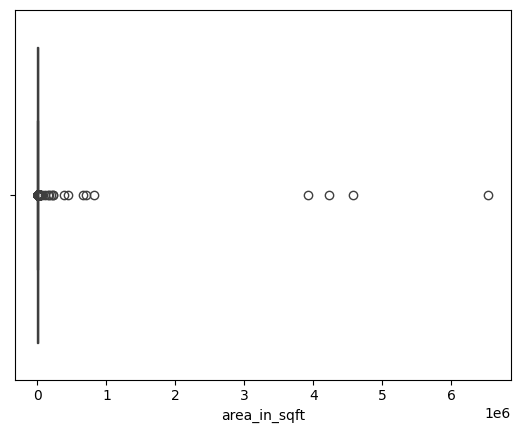

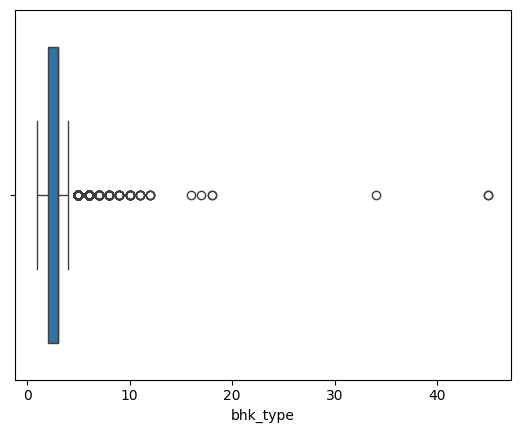

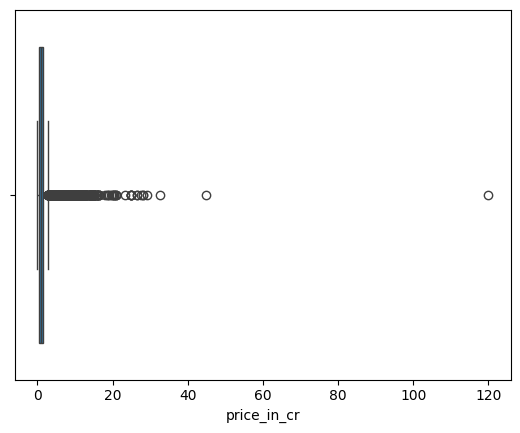

In [18]:
# Univariate Analysis

numeric_cols = ['area_in_sqft','bhk_type','price_in_cr']

for i in numeric_cols:
    sns.boxplot(
        data=df,
        x=i

    )
    plt.xlabel(i)
    plt.show()

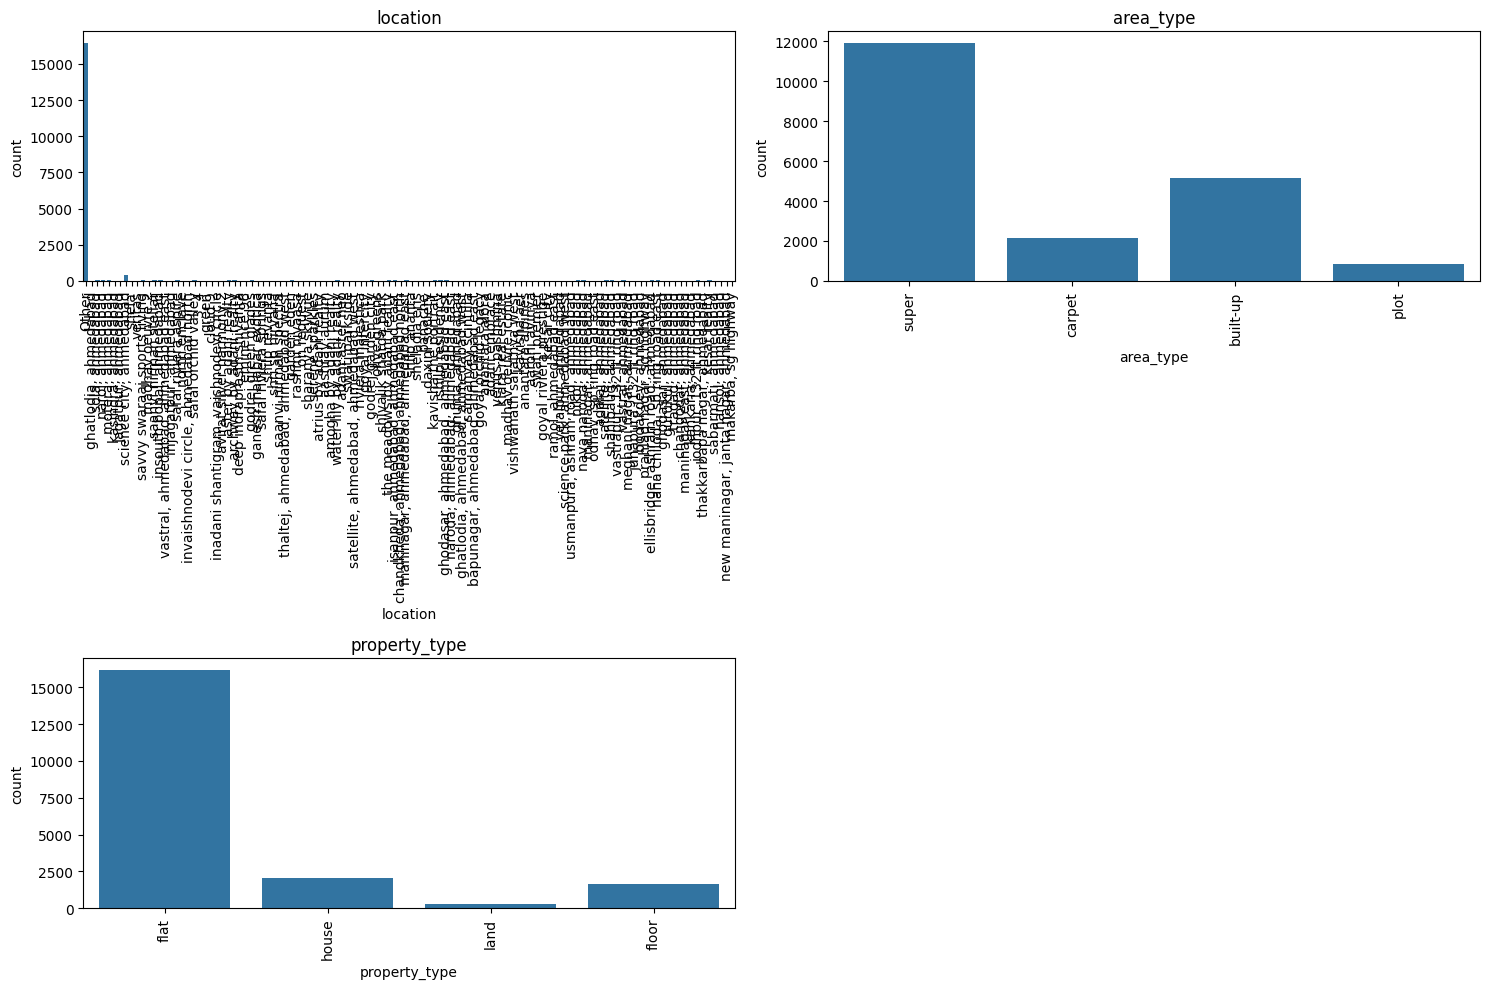

In [19]:
cat_cols = df.select_dtypes(include='object').columns

n = len(cat_cols)
cols = 2                     # Number of plots per row
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=90)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

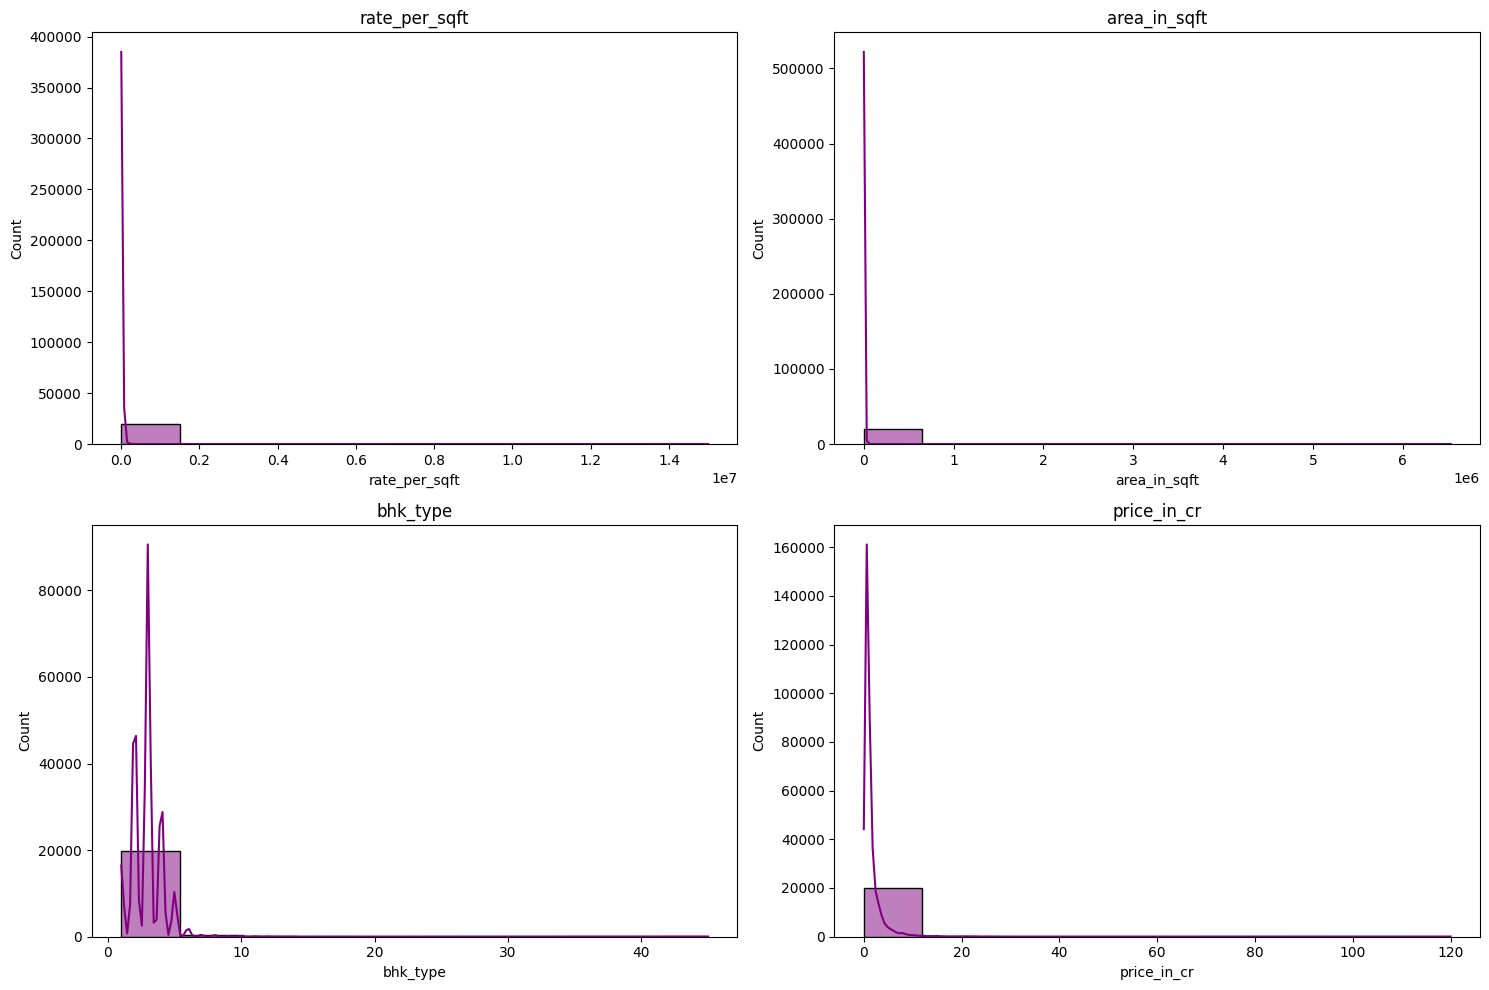

In [20]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(
    nrows=(len(num_cols)+1)//2,
    ncols=2,
    figsize=(15, 5*((len(num_cols)+1)//2))
)

axes = axes.flatten()

j = 0
for i in df.columns:
    if df[i].dtype in ['int64', 'float64']:
        sns.histplot(
            data=df,
            x=i,
            kde=True,
            ax=axes[j],
            bins = 10,
            color = 'purple'
        )
        axes[j].set_title(i)
        j += 1

# Remove empty subplots
for k in range(j, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()
plt.show()

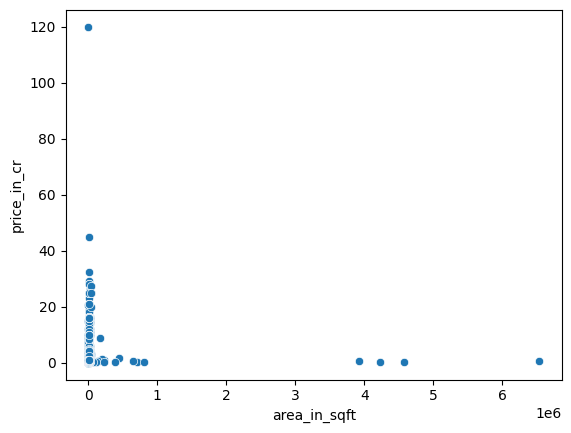

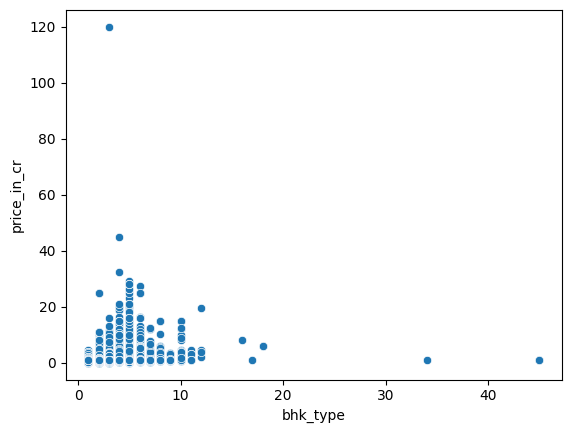

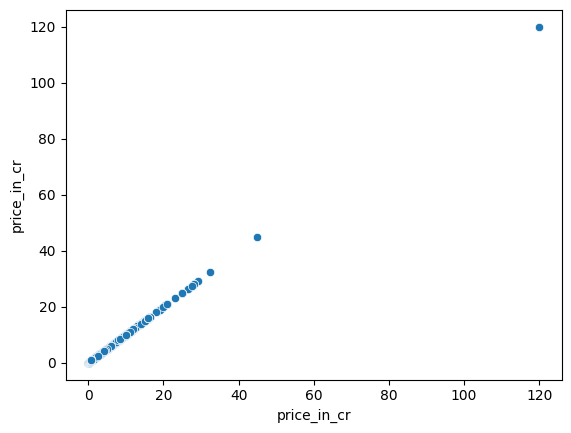

In [21]:
for i in numeric_cols:
    sns.scatterplot(
        data=df,
        x=i,
        y='price_in_cr'
    )
    plt.show()

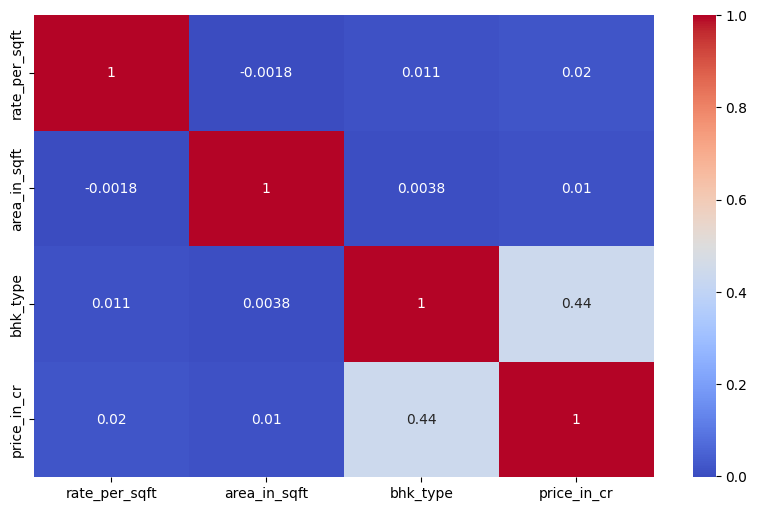

In [22]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [23]:
corr = df[['price_in_cr', 'rate_per_sqft', 'area_in_sqft']].corr()
print(corr)

               price_in_cr  rate_per_sqft  area_in_sqft
price_in_cr       1.000000       0.020325      0.010407
rate_per_sqft     0.020325       1.000000     -0.001849
area_in_sqft      0.010407      -0.001849      1.000000


In [24]:
df.columns

Index(['location', 'rate_per_sqft', 'area_in_sqft', 'area_type',
       'property_type', 'bhk_type', 'price_in_cr'],
      dtype='object')

## 4.Handling Outliers

In [25]:
# Outlier Removal Using IQR Method


outlier_cols = ['price_in_cr', 'area_in_sqft']

print("Original Shape :", df.shape)

for col in outlier_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = df.shape[0]

    df = df[(df[col] >= lower) & (df[col] <= upper)]

    after = df.shape[0]

    print(f"{col}")
    print(f"Rows Removed : {before-after}")
    print(f"Remaining Rows : {after}\n")

print("Final Shape :", df.shape)

Original Shape : (20060, 7)
price_in_cr
Rows Removed : 2153
Remaining Rows : 17907

area_in_sqft
Rows Removed : 935
Remaining Rows : 16972

Final Shape : (16972, 7)


In [26]:
df.shape

(16972, 7)

In [27]:
df.columns

Index(['location', 'rate_per_sqft', 'area_in_sqft', 'area_type',
       'property_type', 'bhk_type', 'price_in_cr'],
      dtype='object')

In [28]:
df['price_in_cr'].sort_values(ascending=False)

,price_in_cr
12056,2.9100
413,2.9100
9107,2.9000
13801,2.9000
4403,2.9000
...,...
7994,0.0270
7964,0.0270
7672,0.0117
16919,0.0100


In [29]:
df['area_in_sqft'] = df['area_in_sqft'].clip(lower, upper)

In [30]:
# Very small properties
print(df[df['area_in_sqft'] <= 100].shape)

# Very large properties
print(df[df['area_in_sqft'] >= 10000].shape)

# Largest 20 properties
df.nlargest(20, 'area_in_sqft')

(293, 7)
(0, 7)


,location,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
14109,Other,5500.0,3251.0,super,flat,4,1.79
101,Other,6153.0,3250.0,super,flat,4,0.85
2185,"science city, ahmedabad",6153.0,3250.0,super,flat,4,0.85
2335,water lily by adani realty,8461.0,3250.0,super,flat,4,2.75
2345,water lily by adani realty,8246.0,3250.0,super,flat,4,2.68
2376,water lily by adani realty,8769.0,3250.0,super,flat,4,2.85
2533,water lily by adani realty,8769.0,3250.0,super,flat,4,2.85
2616,Other,5538.0,3250.0,super,flat,4,1.80
2815,water lily by adani realty,8769.0,3250.0,super,flat,4,2.85
3892,Other,8615.0,3250.0,plot,flat,4,2.80


In [31]:
df.head()

,location,rate_per_sqft,area_in_sqft,area_type,property_type,bhk_type,price_in_cr
0,Other,5009.0,2250.0,super,flat,3,0.8500
1,Other,4377.0,1674.0,super,flat,3,0.7328
2,Other,3931.0,1080.0,super,flat,2,0.4245
3,Other,7198.0,2320.0,super,flat,3,1.6700
4,"ghatlodia, ahmedabad",6153.0,1604.0,carpet,flat,4,0.8500


## Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

X = df.drop('price_in_cr',axis=1)
y = df['price_in_cr']

In [33]:
X_train,X_test,y_train,y_test = train_test_split(
                                            X,
                                            y,
                                            test_size=0.2,
                                            random_state=42
                                          )

In [34]:
from sklearn.preprocessing import LabelEncoder

le_area = LabelEncoder()
le_property = LabelEncoder()
le_location = LabelEncoder()

# area_type
X_train['area_type'] = le_area.fit_transform(X_train['area_type'])
X_test['area_type'] = le_area.transform(X_test['area_type'])

# property_type
X_train['property_type'] = le_property.fit_transform(X_train['property_type'])
X_test['property_type'] = le_property.transform(X_test['property_type'])

# Location
X_train['location'] = le_location.fit_transform(X_train['location'])
X_test['location'] = le_location.transform(X_test['location'])

In [35]:
df.columns

Index(['location', 'rate_per_sqft', 'area_in_sqft', 'area_type',
       'property_type', 'bhk_type', 'price_in_cr'],
      dtype='object')

In [36]:
print(type(X_train))
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [37]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

# Scale area_in_sqft
X_train[['area_in_sqft']] = sc.fit_transform(X_train[['area_in_sqft']])
X_test[['area_in_sqft']] = sc.transform(X_test[['area_in_sqft']])

# Scale bhk_type
X_train[['bhk_type']] = sc.fit_transform(X_train[['bhk_type']])
X_test[['bhk_type']] = sc.transform(X_test[['bhk_type']])

## Train Multiple Models

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error

In [39]:
algorithems = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'ExtraTreesRegressor': ExtraTreesRegressor(random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42),
    'AdaBoostRegressor': AdaBoostRegressor(random_state=42),
    'XGBRegressor': XGBRegressor(random_state=42),
    'SVR': SVR(),
    'KNeighborsRegressor': KNeighborsRegressor()
}

In [40]:
results = []

for name, model in algorithems.items():

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Store result
    results.append({
        'Model': name,
        'R2 Score': r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    })
# Create DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,R2 Score,MAE,MSE,RMSE
0,LinearRegression,0.505136,0.268460,0.146512,0.382769
1,Ridge,0.505136,0.268460,0.146512,0.382768
2,Lasso,0.002142,0.409980,0.295431,0.543535
3,ElasticNet,0.005320,0.409501,0.294490,0.542669
4,DecisionTreeRegressor,0.878800,0.054244,0.035883,0.189428
5,RandomForestRegressor,0.922452,0.049073,0.022959,0.151523
6,ExtraTreesRegressor,0.920351,0.047338,0.023581,0.153561
7,GradientBoostingRegressor,0.901904,0.083213,0.029043,0.170419
8,AdaBoostRegressor,0.723478,0.207066,0.081868,0.286126
9,XGBRegressor,0.915452,0.060743,0.025032,0.158214


In [41]:
# Sort by R2 Score
results_df = results_df.sort_values(by='R2 Score', ascending=False)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,R2 Score,MAE,MSE,RMSE
0,RandomForestRegressor,0.922452,0.049073,0.022959,0.151523
1,ExtraTreesRegressor,0.920351,0.047338,0.023581,0.153561
2,XGBRegressor,0.915452,0.060743,0.025032,0.158214
3,GradientBoostingRegressor,0.901904,0.083213,0.029043,0.170419
4,DecisionTreeRegressor,0.878800,0.054244,0.035883,0.189428
5,AdaBoostRegressor,0.723478,0.207066,0.081868,0.286126
6,Ridge,0.505136,0.268460,0.146512,0.382768
7,LinearRegression,0.505136,0.268460,0.146512,0.382769
8,KNeighborsRegressor,0.462443,0.264187,0.159152,0.398938
9,SVR,0.021438,0.383506,0.289718,0.538254


## Model Tuning

In [42]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [43]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [44]:

GBR = GradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=GBR,
    param_distributions=param_dist,
    n_iter=30,          # Try only 30 combinations
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'learning_rate': 0.05}
0.9369255840847645


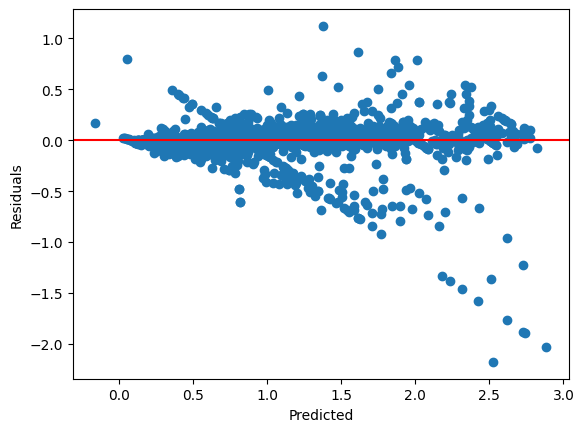

In [45]:
y_pred = random_search.predict(X_test)

plt.scatter(y_pred, y_test - y_pred)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

In [46]:
from sklearn.model_selection import cross_val_score


In [47]:
GBR = GradientBoostingRegressor(
    random_state=42,
    n_estimators=175,
    learning_rate=0.09,
    max_depth=3,
    subsample=0.95
)

In [48]:
GBR.fit(X_train, y_train)
y_pred = GBR.predict(X_test)
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.9100722786067662
0.07618845667902954
0.026624426492468687


In [49]:
cv_scores = cross_val_score(
    GBR,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R² Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores:
[0.93740107 0.93249752 0.91301425 0.91829108 0.91576572]

Average R² Score: 0.9233939274409853
Standard Deviation: 0.009706100565741083


In [50]:
XGB = XGBRegressor(
    random_state=42,
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8
)

In [51]:
XGB.fit(X_train, y_train)
y_pred = XGB.predict(X_test)
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.9154461792975749
0.07311646566302978
0.025033404039062814


In [52]:
cv_scores = cross_val_score(
    XGB,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R² Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores:
[0.93844593 0.93302537 0.91612449 0.92551728 0.91612283]

Average R² Score: 0.9258471821824701
Standard Deviation: 0.008938204044290963


In [53]:
RF = RandomForestRegressor()
Extra = ExtraTreesRegressor()


In [54]:
# Stacking
from sklearn.ensemble import StackingRegressor
estimators = [
    ('rf', RF),
    ('et', Extra),
    ('gbr', GBR),
    ('xgb', XGB)
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    cv=10,
    n_jobs=-1
)


In [55]:
stack.fit(X_train, y_train)

y_pred = stack.predict(X_test)

print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.9267948644510573
0.04989606574907821
0.02167345864098229


In [ ]:
cv_scores = cross_val_score(
    stack,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R² Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
# Voting

from sklearn.ensemble import VotingRegressor
vote = VotingRegressor(
    estimators=[
        ('rf', RF),
        ('extra', Extra),
        ('gbr', GBR),
        ('xgb', XGB)
    ],
    n_jobs=-1
)


In [ ]:
vote.fit(X_train, y_train)

y_pred = vote.predict(X_test)

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("MSE      :", mean_squared_error(y_test, y_pred))

In [ ]:
cv_scores = cross_val_score(
    vote,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R² Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

print(importance.sort_values("Importance", ascending=False))

In [ ]:
from sklearn.metrics import r2_score

# Training Performance
train_pred = stack.predict(X_train)
train_r2 = r2_score(y_train, train_pred)

# Testing Performance
test_pred = stack.predict(X_test)
test_r2 = r2_score(y_test, test_pred)

print("="*40)
print(f"Training R² Score : {train_r2:.4f}")
print(f"Testing R² Score  : {test_r2:.4f}")
print("="*40)

In [ ]:
best_models = {
    "Gradient Boosting": GBR,
    "XGBoost": XGB,
    "Stacking":stack,
    "Voting":vote
}

for name, model in best_models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    print(f"{name}")
    print(f"Mean R² : {scores.mean():.4f}")
    print(f"Std Dev : {scores.std():.4f}")
    print("-" * 40)

In [ ]:
estimators = [
    ('rf', RF),
    ('et', Extra),
    ('gbr', GBR),
    ('xgb', XGB)
]


In [ ]:
algorithms1 = {
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=175,
        learning_rate=0.09,
        max_depth=3,
        subsample=0.95
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8
    ),

    "Stacking": StackingRegressor(
        estimators=estimators,
        final_estimator=LinearRegression(),
        cv=10,
        n_jobs=-1
    ),

    "Voting": VotingRegressor(
        estimators=[
            ("rf", RF),
            ("extra", Extra),
            ("gbr", GBR),
            ("xgb", XGB)
        ],
        n_jobs=-1
    )
}

In [ ]:
from sklearn.model_selection import cross_val_score

results1 = []

for name, model in algorithms1.items():

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Cross Validation
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    # Evaluation
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Store results
    results1.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "CV Mean R2": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4),
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4)
    })

# Create DataFrame
results_df1 = pd.DataFrame(results1)

# Sort by best R²
results_df1 = results_df1.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

results_df1

In [ ]:
print('''
Cross-Validation Results

To evaluate the stability and generalization ability of the trained models, 5-fold cross-validation was performed.
The Stacking Regressor achieved the highest mean R² score of 0.9570 with a low standard deviation (0.0081),
indicating excellent predictive performance and consistent results across different folds.
The Voting Regressor also performed similarly with a mean R² of 0.9569.
''')

In [ ]:
stack.fit(X_train,y_train)

import pickle

with open("stacking_model.pkl", "wb") as file:
    pickle.dump(stack, file)

print("Stacking model saved successfully!")

In [ ]:
import pickle

# Save area encoder
with open("le_area.pkl", "wb") as file:
    pickle.dump(le_area, file)

# Save property type encoder
with open("le_property.pkl", "wb") as file:
    pickle.dump(le_property, file)

# Save location encoder
with open("le_location.pkl", "wb") as file:
    pickle.dump(le_location, file)

print("All encoders saved successfully!")